This notebook is part of a video tutorial! See [here](https://youtu.be/9ZjEUKQhNw4) if you'd like to listen to an explanation of the code.

---

In [1]:
# Load libraries
import numpy as np
import pandas as pd
import torch

In [ ]:
# Load test data
df = pd.read_csv("./framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [3]:
# Prep data to train a logistic regression model on

# Drop rows with any null values
df_clean = df.dropna()

# Separate features (X) and target (y)
X = df_clean.drop('TenYearCHD', axis=1).values
y = df_clean['TenYearCHD'].values

In [4]:
X = torch.from_numpy(X).float()
y = torch.from_numpy(y).float()
print(X.shape)

torch.Size([3656, 15])


# Level 1: Use For Vector Math
This is just using Pytorch as NumPy because we lack imagination.

![meme 1](https://mat3e.github.io/brains/img/0.jpg)

In [5]:
# BAD (numerically unstable AKA get very large outputs if x gets too large or too small)
def sigmoid(x):
    return  1 / (1 + torch.exp(-x))

In [6]:
def sigmoid(x):
    # Applies the most stable formula for each el
    return torch.where(
        x >= 0,
        # e^(-x) won't be large for x > 0
        1 / (1 + torch.exp(-x)),
        # Multiplied above equation by (e^x)/(e^x) since
        # e^(-x) could get large for x < 0
        torch.exp(x) / (1 + torch.exp(x))
    )

def sigmoid_prime(x):
    return sigmoid(x) * (1 - sigmoid(x))

In [7]:
# Logistic regression
def feedforward(X,theta):
    z = X @ theta                 #Weighted input
    a = sigmoid(z)                #Activation
    return a

In [8]:
# Not the best cost function for logistic regression, but simple
def cost_function(pred,y):
    m = y.shape[0]
    
    diff_squared = (pred - y) ** 2
    avg_per_example = torch.sum(diff_squared) / m
    return avg_per_example

In [9]:
def gradient_vectorised(pred,X,y):
    m = y.shape[0]
    
    cost_by_pred = 2 * (pred - y)                           #This returns an m x 1 vector
    sigmoid_out_by_sigmoid_in = sigmoid_prime(X)            #This returns a m x n vector
    X_sum = torch.sum(X, axis=0)                               #X was m x n. Now it's 1 x n
    
    gradient = cost_by_pred @ sigmoid_out_by_sigmoid_in * X_sum
    return gradient / m

In [10]:
def gradient_descent(X,y,theta,learning_rate,num_iters):
    cost_history = []
    for i in range(num_iters):
        print(".", end="")
        pred = feedforward(X,theta)
        cost = cost_function(pred,y)                   #This is just to monitor cost over iterations
        cost_history.append(float(cost))
        
        gradient = gradient_vectorised(pred,X,y)          #This is the backpropagation part
        theta = theta - learning_rate * gradient
    
    return theta, cost_history
    
        
learning_rate = 0.01
num_iters = 100
theta = torch.randn(X.shape[-1])
theta, cost_history = gradient_descent(X,y,theta,learning_rate,num_iters)
print()
print(cost_history)

....................................................................................................
[0.15235230326652527, 0.1561110019683838, 0.22259503602981567, 0.34848466515541077, 0.37518611550331116, 0.3953096568584442, 0.4139156937599182, 0.42261654138565063, 0.4255979061126709, 0.4303987920284271, 0.4350065290927887, 0.43939271569252014, 0.4434661567211151, 0.44721007347106934, 0.4491300582885742, 0.4496673047542572, 0.45100265741348267, 0.4519672095775604, 0.4533454477787018, 0.4538962244987488, 0.4551142752170563, 0.456299364566803, 0.4592406153678894, 0.4597947895526886, 0.4622526168823242, 0.4623431861400604, 0.4635866582393646, 0.46494194865226746, 0.46608006954193115, 0.46654942631721497, 0.4669037163257599, 0.46706217527389526, 0.46816009283065796, 0.46834978461265564, 0.4685446619987488, 0.4687238335609436, 0.4693555533885956, 0.469638854265213, 0.4696389436721802, 0.4696410894393921, 0.4696926772594452, 0.46991294622421265, 0.47018560767173767, 0.47020459175109863, 0.4

# Level 2: I HATE BACKPROPAGATION
Let's use Pytorch to skip the annoying gradient calculations

![meme 2](https://mat3e.github.io/brains/img/1.jpg)

In [11]:
def gradient_descent(X,y,theta,learning_rate,num_iters):
    # Tell Pytorch to track computations for this tensor
    # so we can compute gradients later
    theta = theta.clone().detach().requires_grad_(True)
    cost_history = []
    
    for i in range(num_iters):
        print(".", end="")

        # Pytorch is watching these computations
        pred = feedforward(X, theta)
        cost = cost_function(pred,y)                   
        cost_history.append(float(cost))

        # Automatically computing the gradient with chain rule
        cost.backward()
        
        # Don't track these calculations
        with torch.no_grad():
            # Gradient descent param update if gradient is normal
            if (not torch.isnan(theta.grad).any()):
                theta -= learning_rate * theta.grad
                
        # Reset gradient calc for next iteration
        theta.grad.zero_()

    return theta.detach(), cost_history

In [12]:
# Use while still debugging code.
# torch.autograd.set_detect_anomaly(True)
theta = torch.randn(X.shape[-1])

# Run gradient descent
learning_rate = 0.1
num_iters = 100
theta_with_pytorch, cost_history = gradient_descent(X,y,theta,learning_rate,num_iters)
print()
print(cost_history)

....................................................................................................
[0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971, 0.8476477265357971

Yes, you're seeing correctly this isn't working very well. That's because the functions we're using aren't very numerically stable and oversimplified. Let's learn about more pytorch features that can get this to work better.

# Level 3: Add Some Variety!
Let's say we want to change our cost function. Or our prediction equation. Manually changing code is annoying. Luckily, Pytorch has some libraries to help us experiment!

The magic libraries are [torch.nn](https://pytorch.org/docs/stable/nn.html) and [torch.nn.functional](https://pytorch.org/docs/stable/nn.functional.html)

![meme 3](https://mat3e.github.io/brains/img/2.jpg)

In [13]:
# torch.nn.functional has functions!
import torch.nn.functional as F

bce = F.binary_cross_entropy
cross_entropy = F.cross_entropy
sigmoid = torch.sigmoid
relu = F.relu
linear = F.linear
mse = F.mse_loss

In [14]:
def feedforward(X, theta):
    return sigmoid(linear(X, theta))

pred = feedforward(X, theta_with_pytorch)
# Binary cross entropy is better than MSE for logistic regression
# With pytorch, we can just use it without changing lots of code
cost = bce(pred, y)

In [15]:
def gradient_descent(X,y,theta,learning_rate,num_iters):
    theta = theta.clone().detach().requires_grad_(True)
    cost_history = []
    
    for i in range(num_iters):
        print(".", end="")

        pred = sigmoid(linear(X, theta))
        cost = bce(pred,y)                   
        cost_history.append(float(cost))

        cost.backward()

        with torch.no_grad():
            if (not torch.isnan(theta.grad).any()):
                theta -= learning_rate * theta.grad
        theta.grad.zero_()

    return theta.detach(), cost_history

# Run gradient descent
theta = torch.randn(X.shape[-1])
learning_rate = 0.1
num_iters = 100
theta_with_pytorch, cost_history = gradient_descent(X,y,theta,learning_rate,num_iters)
print()
print(cost_history)

....................................................................................................
[84.67682647705078, 84.69070434570312, 84.67417907714844, 84.67227172851562, 84.67353057861328, 84.67284393310547, 84.6731948852539, 84.67276763916016, 84.67288208007812, 84.67264556884766, 84.6727294921875, 84.6725082397461, 84.67252349853516, 84.67236328125, 84.67235565185547, 84.67223358154297, 84.67215728759766, 84.6720962524414, 84.67201232910156, 84.67192840576172, 84.67182159423828, 84.67173767089844, 84.67166900634766, 84.67157745361328, 84.67149353027344, 84.67139434814453, 84.67131042480469, 84.67121887207031, 84.671142578125, 84.6710433959961, 84.67095184326172, 84.67085266113281, 84.6738052368164, 84.67365264892578, 84.67350769042969, 84.67334747314453, 84.67320251464844, 84.67305755615234, 84.67288208007812, 84.67272186279297, 84.67256164550781, 84.67237854003906, 84.67218780517578, 84.67200469970703, 84.6717758178711, 84.67149353027344, 84.67107391357422, 84.66336059570312

# Level 4: Keeping Variables Organised
Just like Python has 'modules' where coding tools are stored, Pytorch has a **class** called `torch.nn.Module` that's built to store common tools used in neural networks.

One of the common 'tools' used in neural networks are its parameters! A Pytorch class called `torch.nn.Parameter` stores those.

![meme 4](https://mat3e.github.io/brains/img/3.jpg)

In [16]:
# To use the code in torch.nn.Module class, we have to create a child class with our own code
class my_model(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.theta = torch.nn.Parameter(torch.randn(X.shape[-1]))
        
    def forward(self, X):     # This forward method is a 'reserved' name with Pytorch! Careful!
        return sigmoid(linear(X, self.theta))

    def cost(self, pred, y):
        return bce(pred, y)

child_instance = my_model()
pred = child_instance(X)
cost = child_instance.cost(pred, y)

In [17]:
def gradient_descent(X,y,num_iters,learning_rate):
    cost_history = []
    for i in range(num_iters):
        pred = child_instance(X)
        cost = child_instance.cost(pred, y)
        cost_history.append(float(cost))
        
        cost.backward()
        with torch.no_grad():
            for p in child_instance.parameters():        # Really helpful for multiple params
                p -= learning_rate * p.grad
        child_instance.zero_grad()                      # Really helpful for multiple params
    
    return cost_history

In [18]:
learning_rate = 0.1
cost_history = gradient_descent(X,y,num_iters,learning_rate)
print(cost_history)

[15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.2352294921875, 15.235229

# Level 5: But could you just do everything for me?
First, we'll use `torch.nn.[Layer_Name]` as a class that creates its own parameters.

Then, we'll use `torch.nn.Sequential` as a class that stores all these classes.

![meme 5](https://mat3e.github.io/brains/img/4.jpg)

In [19]:
import torch.nn as nn

lr_model = nn.Sequential(        # A predefined class that takes parameters from the layers we pass
    nn.Linear(X.shape[-1],1),       # A predefined class that makes its own parameters
    nn.Sigmoid(),
)

pred = lr_model(X)
# .squeeze() gets rid of extra dimensions. Ex: [1, 5] -> [5]
cost = torch.nn.functional.binary_cross_entropy(pred.squeeze(-1), y)
print(cost)

tensor(3.4923, grad_fn=<BinaryCrossEntropyBackward>)


Also, never mind that whole gradient descent thing. Let's use `torch.optim` to take care of that.

In [20]:
def gradient_desc(mod,X,y,learning_rate,num_iters):
    opt = torch.optim.SGD(mod.parameters(), lr=learning_rate)
    cost_history = []
    
    for i in range(num_iters):
        opt.zero_grad()            # YASSSS
        pred = mod(X)
        cost = torch.nn.functional.binary_cross_entropy(pred.squeeze(-1), y)
        cost_history.append(cost.item())
        
        cost.backward()            # Backpropagation
        opt.step()                 # YASSSS

    return cost_history

learning_rate = 0.1
cost_history = gradient_desc(lr_model,X,y,learning_rate,num_iters)
print(cost_history)

[3.492340087890625, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.7647705078125, 84.76477

Here's another example showing a more complicated model because it's easy to create those now

In [21]:
import torch.nn.functional as F
import torch.nn as nn

neural_net = nn.Sequential(
    nn.Linear(X.shape[-1],10),
    nn.ReLU(),
    nn.Linear(10,5),
    nn.ReLU(),
    nn.Linear(5,1),
    nn.Sigmoid()
)

def gradient_descent(mod,X,y,learning_rate,num_iters):
    opt = torch.optim.SGD(mod.parameters(), lr=learning_rate)
    cost_history = []
    
    for i in range(num_iters):
        opt.zero_grad()            # YASSSS
        pred = mod(X)
        cost = F.binary_cross_entropy(pred.squeeze(-1), y)
        cost_history.append(cost.item())
        
        cost.backward()            # Backpropagation
        opt.step()                 # YASSSS

    return cost_history

learning_rate = 0.01
cost_history = gradient_descent(neural_net, X,y,learning_rate,num_iters)
print(cost_history)

[2.0374622344970703, 0.46326228976249695, 0.8260338306427002, 1.992557406425476, 3.040445327758789, 0.9943167567253113, 0.4832519292831421, 0.45138823986053467, 0.44771507382392883, 0.4471721351146698, 0.44692477583885193, 0.446738600730896, 0.4465724229812622, 0.446419358253479, 0.4462709128856659, 0.4461268186569214, 0.4459856450557709, 0.4458436667919159, 0.4457019567489624, 0.44556501507759094, 0.44543328881263733, 0.44530534744262695, 0.44518157839775085, 0.4450616240501404, 0.4449443817138672, 0.4448281526565552, 0.44471290707588196, 0.44459837675094604, 0.4444851279258728, 0.4443727433681488, 0.4442633390426636, 0.44415539503097534, 0.4440498352050781, 0.44394639134407043, 0.44384604692459106, 0.4437471628189087, 0.44364845752716064, 0.44355207681655884, 0.4434616267681122, 0.443372905254364, 0.44328537583351135, 0.4431993365287781, 0.44311490654945374, 0.44303178787231445, 0.4429493546485901, 0.4428674280643463, 0.4427855610847473, 0.4427044093608856, 0.4426240921020508, 0.4425

# Level 6: Simplify that Data Stuff Too
Some useful libraries for preprocessing are: `torch.utils.data`, `torchvision.transforms`, and `torchtext.data.utils`.

Some useful libraries for data are: `torchvision.datasets`, `torchaudio.datasets`, and `torchtext.datasets`

![meme 6](https://mat3e.github.io/brains/img/5.jpg)

In [22]:
from torch.utils.data import TensorDataset, DataLoader
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32)

def mini_batch_gradient_descent(mod,X,y,learning_rate,num_epochs):
    opt = torch.optim.SGD(mod.parameters(), lr=learning_rate)
    
    for e in range(num_epochs):
        for x,y in loader:           # EASY
            opt.zero_grad()
            pred = mod(x)
            cost = torch.nn.functional.binary_cross_entropy(pred.squeeze(-1), y)

            cost.backward()     
            opt.step()                

learning_rate = 0.1
mini_batch_gradient_descent(neural_net,X,y,learning_rate,3)

# Level 7: And Beyond
See [here](https://pytorch.org/tutorials/beginner/nn_tutorial.html) for a summary or [here](https://pytorch.org/tutorials/beginner/basics/intro.html) for a full tutorial

![meme 7](https://mat3e.github.io/brains/img/6.jpg)

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Load MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), 
                                transforms.Normalize((0.5,), (0.5,))])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

# Define model using Sequential
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

# Setup SGD optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Training loop
model.train()
for epoch in range(3):
    total_loss = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        # Using functional API for loss
        loss = F.cross_entropy(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

print("Training complete!")

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



...

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



/opt/conda/lib/python3.7/site-packages/torchvision/datasets/mnist.py:498: UserWarning: The given NumPy array is not writeable, and PyTorch does not support non-writeable tensors. This means you can write to the underlying (supposedly non-writeable) NumPy array using the tensor. You may want to copy the array to protect its data or make it writeable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  ../torch/csrc/utils/tensor_numpy.cpp:180.)
  return torch.from_numpy(parsed.astype(m[2], copy=False)).view(*s)


Epoch 1, Loss: 0.3783
Epoch 2, Loss: 0.1841
Epoch 3, Loss: 0.1352
Training complete!


I got AI to generate some code to visualise the results of this model.

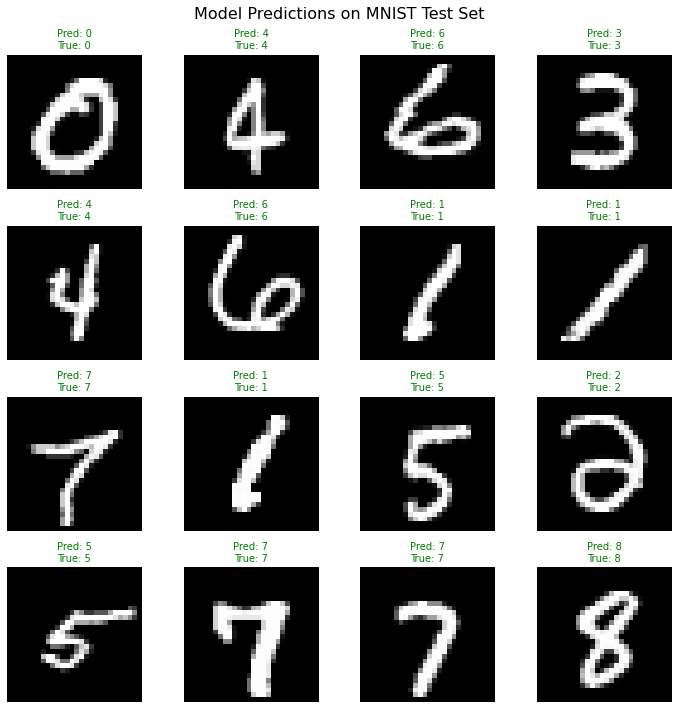

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of test data
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=16, shuffle=True)
images, labels = next(iter(test_loader))

# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    predictions = outputs.argmax(dim=1)

# Create a 4x4 grid of images with predictions
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('Model Predictions on MNIST Test Set', fontsize=16)

for idx, ax in enumerate(axes.flat):
    # Unnormalize and convert to numpy
    img = images[idx].squeeze() * 0.5 + 0.5
    img = img.numpy()
    
    # Display image
    ax.imshow(img, cmap='gray')
    
    # Color code: green for correct, red for incorrect
    color = 'green' if predictions[idx] == labels[idx] else 'red'
    ax.set_title(f'Pred: {predictions[idx].item()}\nTrue: {labels[idx].item()}', 
                 color=color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()